In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cleaned_transactions.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [3]:
df.shape

(514547, 9)

In [4]:
df = df[df["Customer ID"].notna()]

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## Feature Engineering

I created features such as RFM and return-related features that I used to understand churn.

In [6]:
# create total price for each transaction
df = df[df['Price'] > 0]
df['TotalPrice'] = df['Quantity'] * df['Price']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale,30.0


### RFM features

To create RFM features, I first split the data into sales and returns/cancellations. During initial cleaning, I found transactions with negative quantities suggesting returned/cancelled orders. Here I have added this as a feature in the dataset and marked transactions with quantity < 0 as **return/cancelled** and those with quantity >0 as **sale**.

In [7]:
# split the dataset into positive sales and returns/cancellations
returns = df[df['Quantity'] < 0]
purchases = df[df['Quantity'] > 0]

purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'],
                                          errors='coerce')  

#### Create Customer Dataset and Add Features

In [8]:
#add frequency, gross revenue and AOV to the customer dataframe
customer_data = (purchases.groupby('Customer ID').agg(
        gross_revenue = ('TotalPrice', 'sum'),
        frequency = ('InvoiceNo', 'nunique')
        )).reset_index()

customer_data['AOV'] = customer_data['gross_revenue'] / customer_data['frequency']

customer_data.head()


,Customer ID,gross_revenue,frequency,AOV
0,12346.0,372.86,11,33.896364
1,12347.0,1323.32,2,661.660000
2,12348.0,222.16,1,222.160000
3,12349.0,2671.14,3,890.380000
4,12351.0,300.93,1,300.930000


In [9]:
# calculate recency in days
last_purchase = (purchases.groupby(
    'Customer ID')['InvoiceDate'].max()
    .reset_index(name='last_purchase_date')
)

reference_date = purchases['InvoiceDate'].max()

#reference_date = pd.to_datetime(reference_date)
#last_purchase['last_purchase_date'] = pd.to_datetime(last_purchase['last_purchase_date'])

last_purchase['recency_days'] = (
    reference_date - last_purchase['last_purchase_date']).dt.days
last_purchase.head()

,Customer ID,last_purchase_date,recency_days
0,12346.0,2010-06-28 13:53:00,164
1,12347.0,2010-12-07 14:57:00,2
2,12348.0,2010-09-27 14:59:00,73
3,12349.0,2010-10-28 08:23:00,42
4,12351.0,2010-11-29 15:23:00,10


In [10]:
# merge recency back to the customer dataframe
customer_data = customer_data.merge(
    last_purchase[['Customer ID', 'recency_days']],
    on='Customer ID',
    how='left'
)

customer_data.head()

,Customer ID,gross_revenue,frequency,AOV,recency_days
0,12346.0,372.86,11,33.896364,164
1,12347.0,1323.32,2,661.660000,2
2,12348.0,222.16,1,222.160000,73
3,12349.0,2671.14,3,890.380000,42
4,12351.0,300.93,1,300.930000,10


In [11]:
#purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'], errors='coerce')  

# calculate tenure in days
tenure = (purchases
          .groupby('Customer ID')['InvoiceDate']
          .agg(['min', 'max'])
          .reset_index())

tenure['tenure_days'] = (tenure['max'] - tenure['min']).dt.days + 1

customer_data = customer_data.merge(
    tenure[['Customer ID', 'tenure_days']],
    on='Customer ID',
    how='left'
)
customer_data.head()

,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days
0,12346.0,372.86,11,33.896364,164,197
1,12347.0,1323.32,2,661.660000,2,38
2,12348.0,222.16,1,222.160000,73,1
3,12349.0,2671.14,3,890.380000,42,182
4,12351.0,300.93,1,300.930000,10,1


In [12]:
# normalized frequency
customer_data['purchase_rate_monthly'] = (
    customer_data['frequency'] / customer_data['tenure_days'] * 30
)

In [13]:
# sort invoices by customer and date
purchases_sorted = purchases.sort_values(['Customer ID', 'InvoiceDate'])

# Compute the difference between consecutive invoices per customer
purchases_sorted['days_diff'] = (
    purchases_sorted.groupby('Customer ID')['InvoiceDate']
    .diff()  # difference in days
    .dt.days)

In [14]:
days_between_stats = (
    purchases_sorted.groupby('Customer ID')['days_diff']
    .agg(
        avg_days_between='mean',
        std_days_between='std'
    )
    .fillna(0)  # if only one purchase, std is NaN, set to 0
    .reset_index()
)


In [15]:
# merge with customer data
customer_data = customer_data.merge(
    days_between_stats,
    on='Customer ID',
    how='left'
)

customer_data.head()

,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between
0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076
1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346
2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000
3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990
4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000


### Returns-derived features

In [16]:
# Returns only

returns['InvoiceDate'] = pd.to_datetime(returns['InvoiceDate'],
                                          errors='coerce') 
      
returns = df[df['Quantity'] < 0].copy()
returns['returned_quantity'] = returns['Quantity'].abs()
returns.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,TotalPrice,returned_quantity
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,Return/Cancelled,-35.4,12
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,Return/Cancelled,-9.9,6
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,Return/Cancelled,-17.0,4
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,Return/Cancelled,-12.6,6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,Return/Cancelled,-35.4,12


In [17]:
# Aggregate return features per customer
return_features = returns.groupby('Customer ID').agg(
    return_events=('InvoiceNo', 'nunique'),      # how many invoices had returns
    returned_quantity=('returned_quantity', 'sum')  # total items returned
).reset_index()

# Fill customers who had no returns with 0
return_features[['return_events', 'returned_quantity']] = return_features[['return_events', 'returned_quantity']].fillna(0)

return_features.head()

,Customer ID,return_events,returned_quantity
0,12346.0,4,17
1,12349.0,1,5
2,12359.0,2,216
3,12360.0,1,1
4,12380.0,3,29


* return_events: number of purchase occasions that had returns
* returned_quantity: total items returned



In [18]:
# Merge with customer-level purchase data
customer_data = customer_data.merge(
    return_features,
    on='Customer ID',
    how='left'
)

# Fill NaN for customers with no returns
customer_data[['return_events', 'returned_quantity']] = customer_data[['return_events', 'returned_quantity']].fillna(0)

customer_data.head()

,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity
0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0
1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0
2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0
3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0
4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0


In [19]:
# Return rate (proportion of items returned)
purchased_qty = purchases.groupby('Customer ID')['Quantity'].sum()

customer_data = customer_data.set_index('Customer ID')
customer_data['purchased_quantity'] = purchased_qty

customer_data[['purchased_quantity', 'returned_quantity']] = (customer_data[['purchased_quantity', 'returned_quantity']].fillna(0))

customer_data['return_rate'] = customer_data['returned_quantity'] / customer_data['purchased_quantity'].fillna(0)

customer_data.head()

,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate
Customer ID,,,,,,,,,,,,
12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857
12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000
12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000
12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035
12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000


### Revenue-based features

In [20]:
# value of returned items
return_value = returns.groupby('Customer ID')['TotalPrice'].sum().abs()

customer_data['return_value'] = return_value

customer_data[['gross_revenue', 'return_value']] = (customer_data[['gross_revenue', 'return_value']].fillna(0))

customer_data.head()

,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value
Customer ID,,,,,,,,,,,,,
12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60
12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000,0.00
12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000,0.00
12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035,24.15
12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000,0.00


### Net-to-gross revenue ratio

In [21]:
# Net revenue = gross revenue minus revenue lost to returns
customer_data['net_revenue'] = (customer_data['gross_revenue'] - customer_data['return_value']).fillna(0)

# Net-to-gross ratio
customer_data['net_to_gross_ratio'] = (
    customer_data['net_revenue'] / customer_data['gross_revenue']
)

customer_data['net_to_gross_ratio'] = (customer_data['net_to_gross_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
)


customer_data.head()

,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio
Customer ID,,,,,,,,,,,,,,,
12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60,-51.74,-0.138765
12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000,0.00,1323.32,1.000000
12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000,0.00,222.16,1.000000
12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035,24.15,2646.99,0.990959
12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000,0.00,300.93,1.000000


* 1.0 → returned all purchased items. Customer has likely had a poor experience due to *product defects, sizing issues, or unmet expectations*, making them statistically unlikely to shop with the brand again

* 0.7 → returns ~30% of value

* greater than 1.0 → pathological customer (more returned items than bought)

#### Diagnostic of Customers with Negative Monetary Values

Before moving farther, I inspected customers with negative observed net revenue to assess whether this signal reflected disengagement or data window effects. 

In [22]:
negative_net = customer_data[customer_data['net_revenue'] < 0]

negative_net[['frequency', 'recency_days', 'tenure_days',
              'return_rate', 'gross_revenue']].describe()


,frequency,recency_days,tenure_days,return_rate,gross_revenue
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,3.300000,163.350000,60.350000,1.455960,3742.012000
std,3.555574,110.335982,119.663245,0.987204,5944.512284
min,1.000000,0.000000,1.000000,0.000742,20.600000
25%,1.000000,73.000000,1.000000,0.810714,313.117500
50%,2.000000,170.000000,1.000000,1.583333,1011.015000
75%,3.250000,262.000000,12.750000,2.000000,5562.635000
max,13.000000,364.000000,372.000000,3.000000,22710.200000


In [23]:
negative_net.sort_values('tenure_days', ascending=False)

,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio
Customer ID,,,,,,,,,,,,,,,
17017.0,5416.35,13,416.642308,0,372,1.048387,2.146199,16.756622,5.0,30.0,3918,0.007657,5903.05,-486.70,-0.089858
14063.0,22710.20,9,2523.355556,73,294,0.918367,7.435897,39.656947,4.0,4.0,3850,0.001039,26477.40,-3767.20,-0.165881
14912.0,1021.40,4,255.350000,36,281,0.427046,7.971429,34.895209,4.0,15.0,848,0.017689,1114.34,-92.94,-0.090993
12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60,-51.74,-0.138765
15413.0,6798.72,5,1359.744000,326,48,3.125000,1.833333,5.378433,2.0,2.0,2694,0.000742,9330.10,-2531.38,-0.372332
13290.0,208.63,1,208.630000,73,1,30.000000,0.000000,0.000000,2.0,2.0,1,2.000000,417.26,-208.63,-1.000000
13776.0,623.98,2,311.990000,63,1,60.000000,0.000000,0.000000,6.0,6.0,2,3.000000,964.15,-340.17,-0.545162
13112.0,20.60,1,20.600000,176,1,30.000000,0.000000,0.000000,2.0,12.0,11,1.090909,26.04,-5.44,-0.264078
14255.0,1000.63,1,1000.630000,181,1,30.000000,0.000000,0.000000,3.0,3.0,1,3.000000,2442.23,-1441.60,-1.440692


### **Key Findings:**

Out of 20 customers with negative net revenue:

**5 are healthy, long-tenured, window-mismatch customers**

These customers may not be toxic at all. For example, customer 12346: purchased 70 items and returned only 17, a return rate of 0.24 and long-tenured (361 days) with 11 invoices. Perhaps the data window missed the purchases whose items they returned, making their monetary value negative. The negative net revenue is almost certainly due to:
* Returns of items purchased outside your observation window
* *This is a data window artifact, not customer behavior*



**15 are early-life or abnormal-return customers, with:**

  * tenure ≈ 1 day

  * recency > 50 days (i.e. disappeared immediately)

  * return rates between 100–500%

  * returned more items than purchased

  * negative net revenue driven by behavior, not data truncation
  * *This is early churn / bad onboarding / abuse / dissatisfaction / product mismatch / pricing issue / fraud risk*

#### Assign Churn Classes

Earlier in churn definition, I first isolated one-off buyers and labeled them differently and then found the true number of churners (repeat customers who have gone inactive). Here I added the three labels to customer data.

In [24]:
# Function to assign churn class based on recency and purchase count
def assign_churn_class(row, recency_threshold = 90):
    if row['frequency'] == 1:
        return 'one_off_buyer'
    elif row['recency_days'] > recency_threshold:
        return 'churned'
    else:
        return 'active'

customer_data['churn_class'] = customer_data.apply(lambda row:
                                                   assign_churn_class(row, recency_threshold = 90),
                                                   axis = 1)
customer_data.head()

,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio,churn_class
Customer ID,,,,,,,,,,,,,,,,
12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60,-51.74,-0.138765,churned
12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000,0.00,1323.32,1.000000,active
12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000,0.00,222.16,1.000000,one_off_buyer
12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035,24.15,2646.99,0.990959,active
12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000,0.00,300.93,1.000000,one_off_buyer


In [25]:
customer_data.reset_index().head()

,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio,churn_class
0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60,-51.74,-0.138765,churned
1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000,0.00,1323.32,1.000000,active
2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000,0.00,222.16,1.000000,one_off_buyer
3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035,24.15,2646.99,0.990959,active
4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000,0.00,300.93,1.000000,one_off_buyer


### Churn Distribution

Distribution of Unique Customers by Churn Class (with Percentages):


,Count,Percentage
churn_class,,
active,2259,52.39%
one_off_buyer,1419,32.91%
churned,634,14.70%


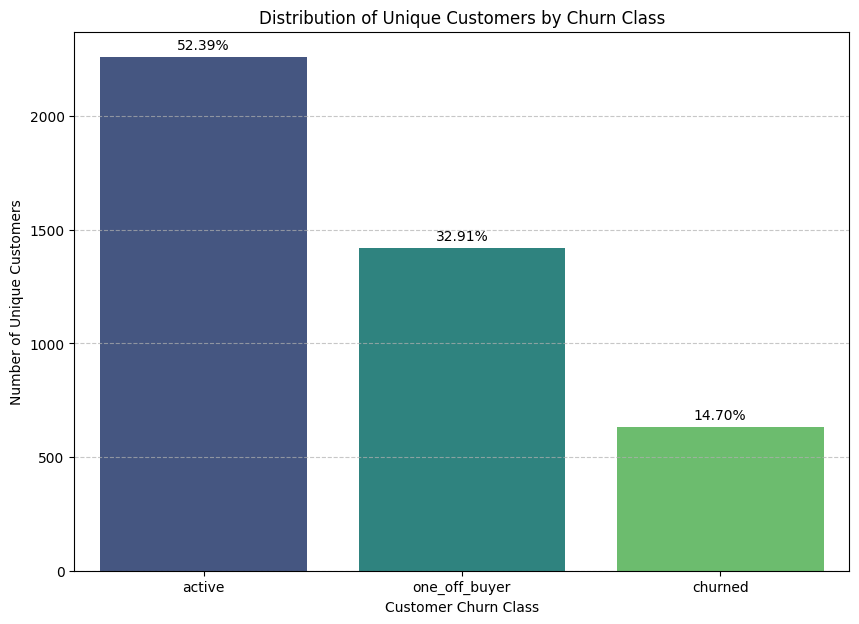

In [26]:
# Get the counts for each churn class
class_counts = customer_data["churn_class"].value_counts()

# Calculate percentages
total_unique_customers = class_counts.sum()
customer_class_percentages = (class_counts / total_unique_customers) * 100

# Combine counts and percentages into a DataFrame for display
churn_class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage': customer_class_percentages
})

churn_class_summary['Percentage'] = churn_class_summary['Percentage'].map('{:.2f}%'.format)

print("Distribution of Unique Customers by Churn Class (with Percentages):")
display(churn_class_summary)

# Re-create the bar plot with percentages on top for better visualization
plt.figure(figsize=(10, 7))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Unique Customers by Churn Class')
plt.xlabel('Customer Churn Class')
plt.ylabel('Number of Unique Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for index, row in churn_class_summary.iterrows():
    plt.text(index, class_counts.loc[index] + 20, # Adjust position of text
             f"{row['Percentage']}", color='black', ha="center", va="bottom")

plt.show()

Churn distribution is correct as defined earlier:

* Active Customers: 2259 (52.4%)

* One-off Buyers: 1419 (32.9%)

* Churned Customers: 634 (14.7%)

* *Over half of our customer base is active, while a significant portion are one-off buyers, and a smaller segment has churned.*

In [27]:
# save the customer-level dataset for future modeling
customer_data.reset_index().to_csv("customer_data_with_churn_labels.csv", index=False)